<a href="https://colab.research.google.com/github/22f1001966/22f1001966_my_new_repository/blob/main/Copy_of_Day_4_hands_on_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Project Bootcamp T2 2026**
## **Day 4: Data Preprocessing - Hands-On Session**


Welcome to the Day 4 Hands-On Session! Today we will apply the concepts discussed in Day 3 (Text Cleaning, Imputation, Encoding, Scaling, Time-based features, PCA, and Pipelines) directly to our dataset.

### **Problem Statement:**
The goal of this competition is to predict a customer’s purchase value based on their multi-session behavior across digital touchpoints. The dataset captures anonymized user interactions such as browser types, traffic sources, device details, and geographical indicators. By modeling these patterns, participants will estimate the purchase potential of each user, helping optimize marketing and engagement strategies.

---

## **Data Preprocessing Exercises: Cleaning, Imputation, Encoding, Scaling & Pipelines**

This notebook covers questions and solutions for common data preprocessing tasks using scikit-learn and pandas.


## Q1. Load the Dataset and Understand its Structure

### Objective:
Load the dataset and understand:
- Number of rows and columns
- Feature names
- Data types
- Target column (`purchaseValue`)
- Sample observations

Understanding structure is the FIRST step in the preprocessing workflow.


In [400]:
import pandas as pd
import numpy as np

In [401]:
# from google.colab import drive
# drive.mount('/content/drive')
# train = pd.read_csv('/content/drive/MyDrive/train_data.csv')
# test = pd.read_csv('/content/drive/MyDrive/test_data.csv')

In [402]:
# 1. Load the Dataset
# Load the dataset (Make sure train_data.csv is uploaded to your Colab environment)
train_url = "https://drive.google.com/file/d/1UCtt9r-jWXo3QbX4m7nA3tKuK-eGbjOE/view?usp=sharing"
test_url = "https://drive.google.com/file/d/1DC_r07Pgm9arUdHtsJTpSQNyzxe2hj3m/view?usp=drive_link"

train_data = "https://drive.google.com/uc?export=download&id=1UCtt9r-jWXo3QbX4m7nA3tKuK-eGbjOE"
test_data = "https://drive.google.com/uc?export=download&id=1DC_r07Pgm9arUdHtsJTpSQNyzxe2hj3m"


train = pd.read_csv(train_data, low_memory=False)
test = pd.read_csv(test_data, low_memory=False)
print(f"Initial Dataset Shape: {train.shape}")

# Replace specific nulls with standard np.nan
null_strings = ['not available in demo dataset', 'not available', '(not set)', 'unknown.unknown']
train.replace(null_strings, np.nan, inplace=True)

train.head()

Initial Dataset Shape: (116023, 52)


/tmp/ipykernel_3313/1914889781.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train.replace(null_strings, np.nan, inplace=True)


,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,NaN,NaN,NaN,medium,Region_2,NaN,NaN,...,NaN,desktop,Social,NaN,1,NaN,1500100799,Americas,False,1.0
1,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,NaN,desktop,Direct,NaN,1,NaN,1495262065,Americas,False,1.0
2,True,0.0,Chrome,NaN,NaN,(not provided),medium,Region_2,NaN,NaN,...,NaN,desktop,Organic Search,NaN,6,NaN,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,NaN,NaN,NaN,medium,Region_4,NaN,NaN,...,NaN,desktop,Social,NaN,1,NaN,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,NaN,desktop,Direct,NaN,66,NaN,1475804633,Americas,False,1.0


In [403]:
#number of rows and columns
train.shape

(116023, 52)

In [404]:
#feature names
train.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

In [405]:
# datatypes
train.dtypes

,0
trafficSource.isTrueDirect,object
purchaseValue,float64
browser,object
device.screenResolution,float64
trafficSource.adContent,object
trafficSource.keyword,object
screenSize,object
geoCluster,object
trafficSource.adwordsClickInfo.slot,object
device.mobileDeviceBranding,float64


In [406]:
train.head()

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,NaN,NaN,NaN,medium,Region_2,NaN,NaN,...,NaN,desktop,Social,NaN,1,NaN,1500100799,Americas,False,1.0
1,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,NaN,desktop,Direct,NaN,1,NaN,1495262065,Americas,False,1.0
2,True,0.0,Chrome,NaN,NaN,(not provided),medium,Region_2,NaN,NaN,...,NaN,desktop,Organic Search,NaN,6,NaN,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,NaN,NaN,NaN,medium,Region_4,NaN,NaN,...,NaN,desktop,Social,NaN,1,NaN,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,NaN,desktop,Direct,NaN,66,NaN,1475804633,Americas,False,1.0


In [407]:
#target column purchaseValue
train['purchaseValue']

,purchaseValue
0,0.0
1,0.0
2,0.0
3,0.0
4,88950000.0
...,...
116018,35180000.0
116019,0.0
116020,0.0
116021,0.0


In [408]:
train['purchaseValue'].value_counts()

,count
purchaseValue,
0.000000e+00,92038
1.699000e+07,445
1.899000e+07,328
3.359000e+07,308
1.999000e+07,288
...,...
2.615000e+07,1
2.436000e+07,1
8.776400e+08,1


In [409]:
#sample observations
train['totals.bounces'].isnull().mean()

np.float64(0.5936322970445516)

## Q2. Perform Detailed Exploratory Data Analysis (EDA)

### Why?
Before preprocessing:
- Detect missing values (Note: The dataset uses strings like 'not available in demo dataset', '(not set)', or '(not provided)' which need to be treated as missing)
- Identify duplicates
- Understand class distribution
- Inspect numerical statistics


In [410]:
# First, replace the string placeholders with actual NaNs
placeholders = ['not available in demo dataset', '(not set)', '(not provided)']
train.replace(placeholders, np.nan, inplace=True)

train.isna().sum()

,0
trafficSource.isTrueDirect,73133
purchaseValue,0
browser,1
device.screenResolution,116023
trafficSource.adContent,113060
trafficSource.keyword,110927
screenSize,0
geoCluster,0
trafficSource.adwordsClickInfo.slot,111742
device.mobileDeviceBranding,116023


In [411]:
# missing values
missing = train.isna().sum()
missing

,0
trafficSource.isTrueDirect,73133
purchaseValue,0
browser,1
device.screenResolution,116023
trafficSource.adContent,113060
trafficSource.keyword,110927
screenSize,0
geoCluster,0
trafficSource.adwordsClickInfo.slot,111742
device.mobileDeviceBranding,116023


In [412]:
train['trafficSource.isTrueDirect'].head()

,trafficSource.isTrueDirect
0,NaN
1,True
2,True
3,NaN
4,True


In [413]:
#missing value percentage
missing_percent = train.isna().mean()*100
missing_percent


,0
trafficSource.isTrueDirect,63.033192
purchaseValue,0.000000
browser,0.000862
device.screenResolution,100.000000
trafficSource.adContent,97.446196
trafficSource.keyword,95.607767
screenSize,0.000000
geoCluster,0.000000
trafficSource.adwordsClickInfo.slot,96.310214
device.mobileDeviceBranding,100.000000


In [414]:
missing_per =  (train.isna().sum()/len(train)) * 100
missing_per


,0
trafficSource.isTrueDirect,63.033192
purchaseValue,0.000000
browser,0.000862
device.screenResolution,100.000000
trafficSource.adContent,97.446196
trafficSource.keyword,95.607767
screenSize,0.000000
geoCluster,0.000000
trafficSource.adwordsClickInfo.slot,96.310214
device.mobileDeviceBranding,100.000000


In [415]:
missing_percent == missing_per

,0
trafficSource.isTrueDirect,True
purchaseValue,True
browser,True
device.screenResolution,True
trafficSource.adContent,True
trafficSource.keyword,True
screenSize,True
geoCluster,True
trafficSource.adwordsClickInfo.slot,True
device.mobileDeviceBranding,True


In [416]:
# Understand class distribution
#import pandas as pd

# Assume 'target' is your label column
class_counts = train['purchaseValue'].value_counts()
class_percentages = train['purchaseValue'].value_counts(normalize=True) * 100

print(class_counts)
print(class_percentages)



purchaseValue
0.000000e+00    92038
1.699000e+07      445
1.899000e+07      328
3.359000e+07      308
1.999000e+07      288
                ...  
2.615000e+07        1
2.436000e+07        1
8.776400e+08        1
1.488000e+08        1
1.424250e+09        1
Name: count, Length: 6766, dtype: int64
purchaseValue
0.000000e+00    79.327375
1.699000e+07     0.383545
1.899000e+07     0.282703
3.359000e+07     0.265465
1.999000e+07     0.248227
                  ...    
2.615000e+07     0.000862
2.436000e+07     0.000862
8.776400e+08     0.000862
1.488000e+08     0.000862
1.424250e+09     0.000862
Name: proportion, Length: 6766, dtype: float64


In [417]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116022 non-null  object 
 3   device.screenResolution                       0 non-null       float64
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         5096 non-null    object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   0 

In [418]:
train.describe()

,purchaseValue,device.screenResolution,device.mobileDeviceBranding,device.mobileInputSelector,userId,device.mobileDeviceMarketingName,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,...,locationZone,device.mobileDeviceModel,totals.bounces,date,device.language,device.browserVersion,totalHits,device.screenColors,sessionStart,new_visits
count,1.160230e+05,0.0,0.0,0.0,116023.000000,0.0,116023.000000,0.0,116023.000000,0.0,...,116023.0,0.0,47148.0,1.160230e+05,0.0,0.0,116023.000000,0.0,1.160230e+05,80518.0
mean,2.656393e+07,NaN,NaN,NaN,61094.356231,NaN,0.037019,NaN,2.691311,NaN,...,8.0,NaN,1.0,2.016860e+07,NaN,NaN,10.607371,NaN,1.493429e+09,1.0
std,2.051825e+08,NaN,NaN,NaN,35240.756859,NaN,0.188808,NaN,10.451613,NaN,...,0.0,NaN,0.0,6.182322e+03,NaN,NaN,19.629576,NaN,1.528798e+07,0.0
min,0.000000e+00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,1.000000,NaN,...,8.0,NaN,1.0,2.016080e+07,NaN,NaN,1.000000,NaN,1.470035e+09,1.0
25%,0.000000e+00,NaN,NaN,NaN,30603.500000,NaN,0.000000,NaN,1.000000,NaN,...,8.0,NaN,1.0,2.016112e+07,NaN,NaN,1.000000,NaN,1.480066e+09,1.0
50%,0.000000e+00,NaN,NaN,NaN,61014.000000,NaN,0.000000,NaN,1.000000,NaN,...,8.0,NaN,1.0,2.017041e+07,NaN,NaN,2.000000,NaN,1.491646e+09,1.0
75%,0.000000e+00,NaN,NaN,NaN,91616.500000,NaN,0.000000,NaN,2.000000,NaN,...,8.0,NaN,1.0,2.017091e+07,NaN,NaN,12.000000,NaN,1.505079e+09,1.0
max,2.312950e+10,NaN,NaN,NaN,122276.000000,NaN,1.000000,NaN,447.000000,NaN,...,8.0,NaN,1.0,2.018043e+07,NaN,NaN,500.000000,NaN,1.525157e+09,1.0


In [419]:
print(train.shape)
print(test.shape)

(116023, 52)
(29006, 51)


In [420]:
type(train)

pandas.core.frame.DataFrame

In [421]:
train.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

In [422]:
train['device.isMobile'].head()

,device.isMobile
0,False
1,False
2,False
3,False
4,False


In [423]:
train.select_dtypes(include='bool')

,device.isMobile
0,False
1,False
2,False
3,False
4,False
...,...
116018,False
116019,False
116020,False
116021,False


In [424]:
train.select_dtypes(include='number').head()


,purchaseValue,device.screenResolution,device.mobileDeviceBranding,device.mobileInputSelector,userId,device.mobileDeviceMarketingName,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,...,locationZone,device.mobileDeviceModel,totals.bounces,date,device.language,device.browserVersion,totalHits,device.screenColors,sessionStart,new_visits
0,0.0,NaN,NaN,NaN,61421,NaN,0,NaN,1,NaN,...,8,NaN,1.0,20170714,NaN,NaN,1,NaN,1500100799,1.0
1,0.0,NaN,NaN,NaN,72287,NaN,0,NaN,1,NaN,...,8,NaN,1.0,20170519,NaN,NaN,1,NaN,1495262065,1.0
2,0.0,NaN,NaN,NaN,25180,NaN,0,NaN,2,NaN,...,8,NaN,NaN,20171020,NaN,NaN,6,NaN,1508510328,NaN
3,0.0,NaN,NaN,NaN,41295,NaN,0,NaN,1,NaN,...,8,NaN,1.0,20170103,NaN,NaN,1,NaN,1483431838,1.0
4,88950000.0,NaN,NaN,NaN,113697,NaN,0,NaN,1,NaN,...,8,NaN,NaN,20161006,NaN,NaN,66,NaN,1475804633,1.0


In [425]:
train.columns.difference(test.columns)

Index(['purchaseValue'], dtype='object')

In [426]:
test.select_dtypes(include='number').head()

,date,totals.bounces,totalHits,new_visits,pageViews,totals.visits,trafficSource.adwordsClickInfo.page,sessionId,sessionNumber,sessionStart,userId,locationZone,gclIdPresent
0,20170508,NaN,11,NaN,10.0,1,NaN,1494262567,2,1494262567,59555,8,0
1,20170405,NaN,9,1.0,9.0,1,NaN,1491433811,1,1491433811,6394,8,0
2,20170308,NaN,2,1.0,2.0,1,NaN,1489001815,1,1489001815,38969,8,0
3,20171113,NaN,3,NaN,3.0,1,NaN,1510593024,30,1510593024,120027,8,0
4,20161212,NaN,7,1.0,7.0,1,NaN,1481559809,1,1481559809,69453,8,0


In [427]:
y_train=train["purchaseValue"].head()
y_train

,purchaseValue
0,0.0
1,0.0
2,0.0
3,0.0
4,88950000.0


#***In the train_data.csv The categorical datatypes are 37 and numerical datatypes are 14 and booleans are 1***

In [428]:
train.dtypes.value_counts()

,count
object,24
float64,18
int64,9
bool,1


In [429]:
train.select_dtypes(include='number')

,purchaseValue,device.screenResolution,device.mobileDeviceBranding,device.mobileInputSelector,userId,device.mobileDeviceMarketingName,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,...,locationZone,device.mobileDeviceModel,totals.bounces,date,device.language,device.browserVersion,totalHits,device.screenColors,sessionStart,new_visits
0,0.0,NaN,NaN,NaN,61421,NaN,0,NaN,1,NaN,...,8,NaN,1.0,20170714,NaN,NaN,1,NaN,1500100799,1.0
1,0.0,NaN,NaN,NaN,72287,NaN,0,NaN,1,NaN,...,8,NaN,1.0,20170519,NaN,NaN,1,NaN,1495262065,1.0
2,0.0,NaN,NaN,NaN,25180,NaN,0,NaN,2,NaN,...,8,NaN,NaN,20171020,NaN,NaN,6,NaN,1508510328,NaN
3,0.0,NaN,NaN,NaN,41295,NaN,0,NaN,1,NaN,...,8,NaN,1.0,20170103,NaN,NaN,1,NaN,1483431838,1.0
4,88950000.0,NaN,NaN,NaN,113697,NaN,0,NaN,1,NaN,...,8,NaN,NaN,20161006,NaN,NaN,66,NaN,1475804633,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,35180000.0,NaN,NaN,NaN,109014,NaN,0,NaN,1,NaN,...,8,NaN,NaN,20170717,NaN,NaN,28,NaN,1500318402,1.0
116019,0.0,NaN,NaN,NaN,66111,NaN,0,NaN,1,NaN,...,8,NaN,1.0,20161108,NaN,NaN,1,NaN,1478624150,1.0
116020,0.0,NaN,NaN,NaN,97614,NaN,0,NaN,2,NaN,...,8,NaN,1.0,20160805,NaN,NaN,1,NaN,1470384216,NaN
116021,0.0,NaN,NaN,NaN,71050,NaN,0,NaN,1,NaN,...,8,NaN,NaN,20171002,NaN,NaN,2,NaN,1506953297,1.0


In [430]:
train.select_dtypes(exclude='number')

,trafficSource.isTrueDirect,browser,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,trafficSource.campaign,geoNetwork.networkDomain,geoNetwork.region,...,locationCountry,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,geoNetwork.city,geoNetwork.metro,trafficSource.referralPath,deviceType,userChannel,geoNetwork.continent,device.isMobile
0,NaN,Edge,NaN,NaN,medium,Region_2,NaN,NaN,domain1,Washington,...,United States,NaN,Not Socially Engaged,Redmond,Seattle-Tacoma WA,/intl/hr/yt/about/,desktop,Social,Americas,False
1,True,Chrome,NaN,NaN,medium,Region_3,NaN,NaN,domain3,California,...,United States,NaN,Not Socially Engaged,Mountain View,San Francisco-Oakland-San Jose CA,NaN,desktop,Direct,Americas,False
2,True,Chrome,NaN,NaN,medium,Region_2,NaN,NaN,domain1,Lombardy,...,Italy,NaN,Not Socially Engaged,Milan,NaN,NaN,desktop,Organic Search,Europe,False
3,NaN,Internet Explorer,NaN,NaN,medium,Region_4,NaN,NaN,domain3,NaN,...,Japan,NaN,Not Socially Engaged,NaN,NaN,/yt/about/ja/,desktop,Social,Asia,False
4,True,Chrome,NaN,NaN,medium,Region_3,NaN,NaN,domain1,NaN,...,United States,NaN,Not Socially Engaged,NaN,NaN,NaN,desktop,Direct,Americas,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,NaN,Chrome,NaN,NaN,medium,Region_3,NaN,NaN,domain1,New York,...,United States,NaN,Not Socially Engaged,New York,New York NY,/,desktop,Referral,Americas,False
116019,True,Chrome,NaN,NaN,medium,Region_5,NaN,NaN,domain2,California,...,United States,NaN,Not Socially Engaged,Mountain View,San Francisco-Oakland-San Jose CA,NaN,desktop,Direct,Americas,False
116020,True,Chrome,NaN,NaN,medium,Region_1,NaN,NaN,domain2,Delhi,...,India,NaN,Not Socially Engaged,New Delhi,NaN,/google-analytics-launches-public-demo-account...,desktop,Referral,Asia,False
116021,NaN,Chrome,NaN,NaN,medium,Region_5,NaN,NaN,domain1,Tennessee,...,United States,NaN,Not Socially Engaged,Nashville,Nashville TN,NaN,desktop,Organic Search,Americas,False


In [431]:
train.select_dtypes(exclude='object')

,purchaseValue,device.screenResolution,device.mobileDeviceBranding,device.mobileInputSelector,userId,device.mobileDeviceMarketingName,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,...,device.mobileDeviceModel,totals.bounces,date,device.language,device.browserVersion,totalHits,device.screenColors,sessionStart,device.isMobile,new_visits
0,0.0,NaN,NaN,NaN,61421,NaN,0,NaN,1,NaN,...,NaN,1.0,20170714,NaN,NaN,1,NaN,1500100799,False,1.0
1,0.0,NaN,NaN,NaN,72287,NaN,0,NaN,1,NaN,...,NaN,1.0,20170519,NaN,NaN,1,NaN,1495262065,False,1.0
2,0.0,NaN,NaN,NaN,25180,NaN,0,NaN,2,NaN,...,NaN,NaN,20171020,NaN,NaN,6,NaN,1508510328,False,NaN
3,0.0,NaN,NaN,NaN,41295,NaN,0,NaN,1,NaN,...,NaN,1.0,20170103,NaN,NaN,1,NaN,1483431838,False,1.0
4,88950000.0,NaN,NaN,NaN,113697,NaN,0,NaN,1,NaN,...,NaN,NaN,20161006,NaN,NaN,66,NaN,1475804633,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,35180000.0,NaN,NaN,NaN,109014,NaN,0,NaN,1,NaN,...,NaN,NaN,20170717,NaN,NaN,28,NaN,1500318402,False,1.0
116019,0.0,NaN,NaN,NaN,66111,NaN,0,NaN,1,NaN,...,NaN,1.0,20161108,NaN,NaN,1,NaN,1478624150,False,1.0
116020,0.0,NaN,NaN,NaN,97614,NaN,0,NaN,2,NaN,...,NaN,1.0,20160805,NaN,NaN,1,NaN,1470384216,False,NaN
116021,0.0,NaN,NaN,NaN,71050,NaN,0,NaN,1,NaN,...,NaN,NaN,20171002,NaN,NaN,2,NaN,1506953297,False,1.0


In [432]:
missing = train.isnull().sum().sort_values(ascending=False)
missing
#missing1 = test.isnull().sum().sort_values(ascending=False)
#missing1

,0
device.screenResolution,116023
device.operatingSystemVersion,116023
device.mobileDeviceBranding,116023
device.mobileInputSelector,116023
device.flashVersion,116023
device.mobileDeviceMarketingName,116023
device.screenColors,116023
device.browserVersion,116023
device.mobileDeviceModel,116023
device.browserSize,116023


In [433]:
missing_percent=(train.isnull().mean()*100).sort_values(ascending=False)
missing_percent

,0
device.screenResolution,100.000000
device.operatingSystemVersion,100.000000
device.mobileDeviceBranding,100.000000
device.mobileInputSelector,100.000000
device.flashVersion,100.000000
device.mobileDeviceMarketingName,100.000000
device.screenColors,100.000000
device.browserVersion,100.000000
device.mobileDeviceModel,100.000000
device.browserSize,100.000000


In [434]:

duplicated_count=train.duplicated().sum()

print(f"number of duplicated rows:{duplicated_count}")

duplicated_percentage=duplicated_count/len(train)*100

print(f"percentage  of duplicated rows:{duplicated_percentage}")
print(len(train))

number of duplicated rows:236
percentage  of duplicated rows:0.20340794497642709
116023


In [435]:
duplicates = train[train.duplicated(keep=False)]
duplicates.sort_values(by=list(train.columns))

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
32981,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Organic Search,NaN,3,NaN,1471996440,Americas,False,NaN
100050,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Organic Search,NaN,3,NaN,1471996440,Americas,False,NaN
20822,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Direct,NaN,1,NaN,1491194685,Asia,False,1.0
105730,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Direct,NaN,1,NaN,1491194685,Asia,False,1.0
38914,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Direct,NaN,1,NaN,1491031938,Americas,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86394,NaN,477240000.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Organic Search,NaN,113,NaN,1471876718,Americas,False,1.0
91403,NaN,503460000.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Organic Search,NaN,49,NaN,1498588440,Americas,False,1.0
109524,NaN,503460000.0,Chrome,NaN,NaN,NaN,medium,Region_1,NaN,NaN,...,NaN,desktop,Organic Search,NaN,49,NaN,1498588440,Americas,False,1.0
7029,NaN,567030000.0,Chrome,NaN,NaN,NaN,medium,Region_5,NaN,NaN,...,NaN,desktop,Organic Search,NaN,47,NaN,1484795003,Americas,False,NaN


In [436]:
print("shape of  train before dropping duplicates ",train.shape)
train_no_duplicates=train.drop_duplicates()
print("shape of  train after dropping duplicates ",train_no_duplicates.shape)
print(train.shape[0]-(train_no_duplicates.shape[0]))

shape of  train before dropping duplicates  (116023, 52)
shape of  train after dropping duplicates  (115787, 52)
236


In [437]:
summary = train.describe()
summary

,purchaseValue,device.screenResolution,device.mobileDeviceBranding,device.mobileInputSelector,userId,device.mobileDeviceMarketingName,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,...,locationZone,device.mobileDeviceModel,totals.bounces,date,device.language,device.browserVersion,totalHits,device.screenColors,sessionStart,new_visits
count,1.160230e+05,0.0,0.0,0.0,116023.000000,0.0,116023.000000,0.0,116023.000000,0.0,...,116023.0,0.0,47148.0,1.160230e+05,0.0,0.0,116023.000000,0.0,1.160230e+05,80518.0
mean,2.656393e+07,NaN,NaN,NaN,61094.356231,NaN,0.037019,NaN,2.691311,NaN,...,8.0,NaN,1.0,2.016860e+07,NaN,NaN,10.607371,NaN,1.493429e+09,1.0
std,2.051825e+08,NaN,NaN,NaN,35240.756859,NaN,0.188808,NaN,10.451613,NaN,...,0.0,NaN,0.0,6.182322e+03,NaN,NaN,19.629576,NaN,1.528798e+07,0.0
min,0.000000e+00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,1.000000,NaN,...,8.0,NaN,1.0,2.016080e+07,NaN,NaN,1.000000,NaN,1.470035e+09,1.0
25%,0.000000e+00,NaN,NaN,NaN,30603.500000,NaN,0.000000,NaN,1.000000,NaN,...,8.0,NaN,1.0,2.016112e+07,NaN,NaN,1.000000,NaN,1.480066e+09,1.0
50%,0.000000e+00,NaN,NaN,NaN,61014.000000,NaN,0.000000,NaN,1.000000,NaN,...,8.0,NaN,1.0,2.017041e+07,NaN,NaN,2.000000,NaN,1.491646e+09,1.0
75%,0.000000e+00,NaN,NaN,NaN,91616.500000,NaN,0.000000,NaN,2.000000,NaN,...,8.0,NaN,1.0,2.017091e+07,NaN,NaN,12.000000,NaN,1.505079e+09,1.0
max,2.312950e+10,NaN,NaN,NaN,122276.000000,NaN,1.000000,NaN,447.000000,NaN,...,8.0,NaN,1.0,2.018043e+07,NaN,NaN,500.000000,NaN,1.525157e+09,1.0


In [438]:
cat = train.select_dtypes(include='object').columns
len(cat)

24

In [439]:
num = train.select_dtypes(exclude='object').columns
num

Index(['purchaseValue', 'device.screenResolution',
       'device.mobileDeviceBranding', 'device.mobileInputSelector', 'userId',
       'device.mobileDeviceMarketingName', 'gclIdPresent',
       'device.operatingSystemVersion', 'sessionNumber', 'device.flashVersion',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId',
       'browserMajor', 'device.browserSize',
       'trafficSource.adwordsClickInfo.page', 'pageViews', 'locationZone',
       'device.mobileDeviceModel', 'totals.bounces', 'date', 'device.language',
       'device.browserVersion', 'totalHits', 'device.screenColors',
       'sessionStart', 'device.isMobile', 'new_visits'],
      dtype='object')

In [440]:
len(num)

28

In [441]:
len(train.select_dtypes(include='datetime').columns)

0

In [442]:
train.columns.nunique()

52

In [443]:
train.isna().sum().sort_values(ascending=False)

,0
device.screenResolution,116023
device.operatingSystemVersion,116023
device.mobileDeviceBranding,116023
device.mobileInputSelector,116023
device.flashVersion,116023
device.mobileDeviceMarketingName,116023
device.screenColors,116023
device.browserVersion,116023
device.mobileDeviceModel,116023
device.browserSize,116023


In [444]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29006 entries, 0 to 29005
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   userChannel                                   29006 non-null  object 
 1   date                                          29006 non-null  int64  
 2   browser                                       29006 non-null  object 
 3   device.browserSize                            29006 non-null  object 
 4   device.browserVersion                         29006 non-null  object 
 5   deviceType                                    29006 non-null  object 
 6   device.flashVersion                           29006 non-null  object 
 7   device.isMobile                               29006 non-null  bool   
 8   device.language                               29006 non-null  object 
 9   device.mobileDeviceBranding                   29006 non-null 

In [445]:
test.describe()

,date,totals.bounces,totalHits,new_visits,pageViews,totals.visits,trafficSource.adwordsClickInfo.page,sessionId,sessionNumber,sessionStart,userId,locationZone,gclIdPresent
count,2.900600e+04,11732.0,29006.000000,20094.0,29003.000000,29006.0,1107.000000,2.900600e+04,29006.000000,2.900600e+04,29006.000000,29006.0,29006.000000
mean,2.016855e+07,1.0,10.659519,1.0,8.470813,1.0,1.015357,1.493320e+09,2.595980,1.493320e+09,61327.854134,8.0,0.038268
std,6.200443e+03,0.0,19.771218,0.0,14.561705,0.0,0.177227,1.532493e+07,9.333323,1.532493e+07,35253.344987,0.0,0.191846
min,2.016080e+07,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.470035e+09,1.000000,1.470035e+09,8.000000,8.0,0.000000
25%,2.016112e+07,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.479931e+09,1.000000,1.479931e+09,31006.500000,8.0,0.000000
50%,2.017041e+07,1.0,2.000000,1.0,2.000000,1.0,1.000000,1.491492e+09,1.000000,1.491492e+09,61430.500000,8.0,0.000000
75%,2.017091e+07,1.0,12.000000,1.0,10.000000,1.0,1.000000,1.505148e+09,2.000000,1.505148e+09,91866.250000,8.0,0.000000
max,2.018043e+07,1.0,500.000000,1.0,466.000000,1.0,5.000000,1.525152e+09,334.000000,1.525152e+09,122268.000000,8.0,1.000000


In [446]:
# feature cardinality in each column to decide encoding technique , one-hot or label
for col in train.columns:
  print(col, train[col].nunique())

trafficSource.isTrueDirect 1
purchaseValue 6766
browser 33
device.screenResolution 0
trafficSource.adContent 53
trafficSource.keyword 565
screenSize 1
geoCluster 5
trafficSource.adwordsClickInfo.slot 3
device.mobileDeviceBranding 0
device.mobileInputSelector 0
userId 100499
trafficSource.campaign 27
device.mobileDeviceMarketingName 0
geoNetwork.networkDomain 3
gclIdPresent 2
device.operatingSystemVersion 0
sessionNumber 230
device.flashVersion 0
geoNetwork.region 386
trafficSource 160
totals.visits 1
geoNetwork.networkLocation 0
sessionId 107379
os 17
geoNetwork.subContinent 22
trafficSource.medium 6
trafficSource.adwordsClickInfo.isVideoAd 1
browserMajor 0
locationCountry 192
device.browserSize 0
trafficSource.adwordsClickInfo.adNetworkType 2
socialEngagementType 1
geoNetwork.city 693
trafficSource.adwordsClickInfo.page 5
geoNetwork.metro 102
pageViews 175
locationZone 1
device.mobileDeviceModel 0
trafficSource.referralPath 941
totals.bounces 1
date 638
device.language 0
deviceType 3


In [447]:
train['device.screenResolution'].value_counts()

,count
device.screenResolution,


In [448]:
train['screenSize'].value_counts()

,count
screenSize,
medium,116023


In [449]:
duplicate_count=train.duplicated().sum()
duplicate_count

np.int64(236)

In [450]:

duplicate_percentage =duplicate_count/len(train)*100
duplicate_percentage

np.float64(0.20340794497642709)

In [451]:
train['purchaseValue'].describe()

,purchaseValue
count,1.160230e+05
mean,2.656393e+07
std,2.051825e+08
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.312950e+10


In [452]:

#percentage of purchaseValue 0
(train['purchaseValue']==0).sum()/len(train)*100

np.float64(79.32737474466269)

In [453]:
train['pageViews'].describe()

,pageViews
count,116015.000000
mean,8.412352
std,14.344937
min,1.000000
25%,1.000000
50%,2.000000
75%,10.000000
max,469.000000


#Distribution of numerical variables
###*purchaseValue*  
###*pageViews*

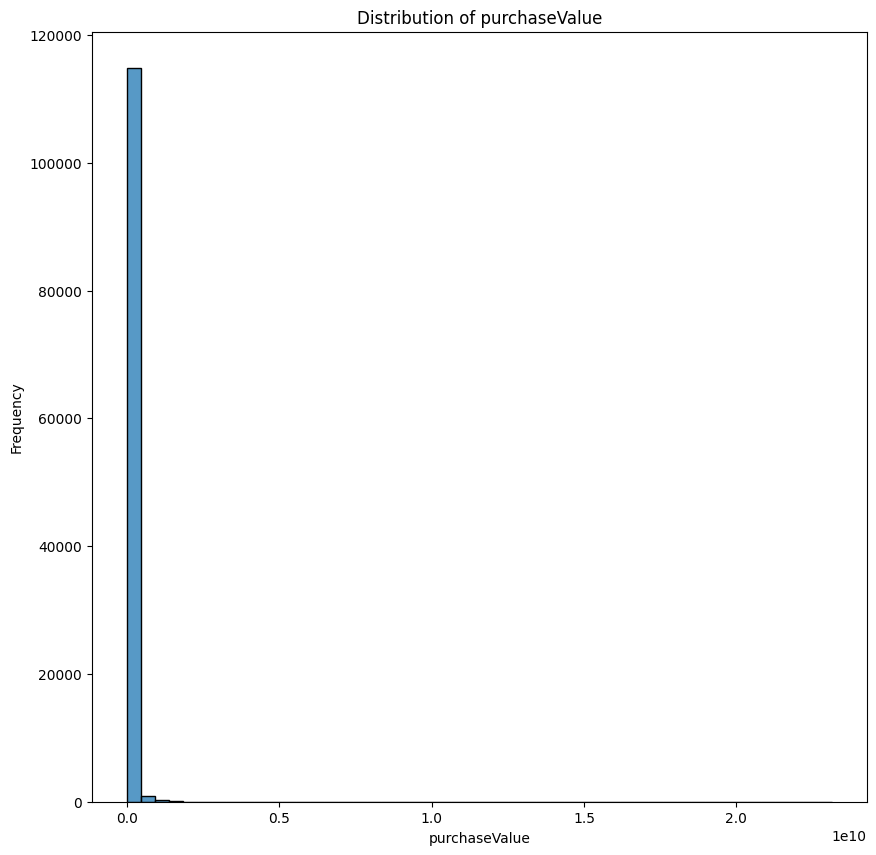

In [454]:
#purchaseValue
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
sns.histplot(train['purchaseValue'],bins=50)
plt.title('Distribution of purchaseValue')
plt.xlabel('purchaseValue')
plt.ylabel('Frequency')
plt.show()

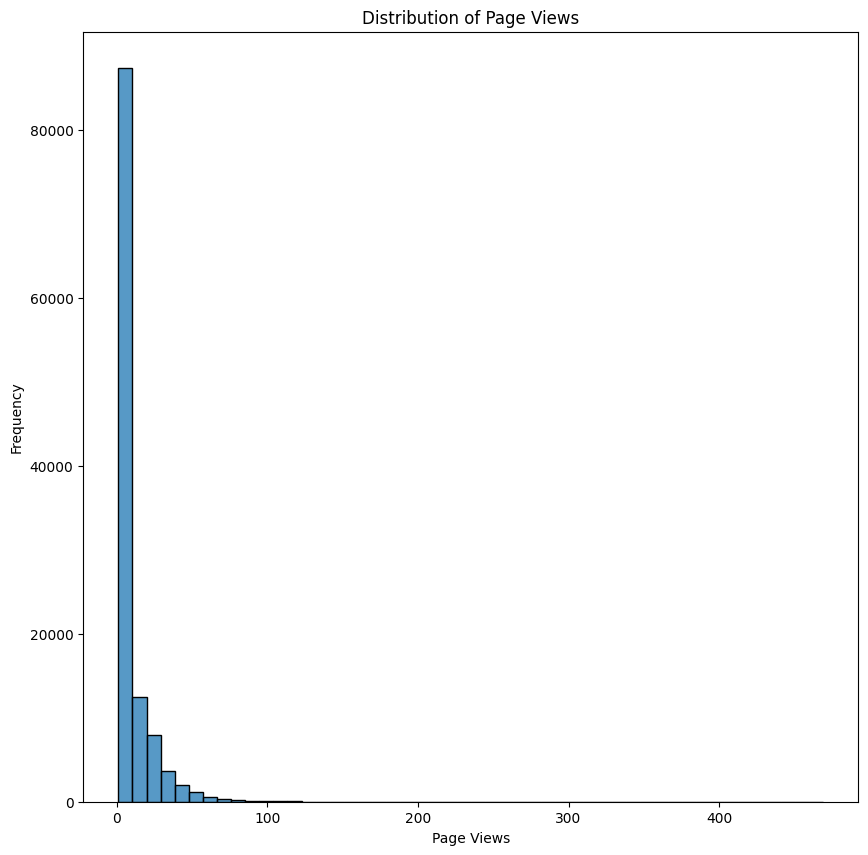

In [455]:
#pageViews
plt.figure(figsize=(10,10))
sns.histplot(train['pageViews'],bins=50)


plt.title('Distribution of Page Views')
plt.xlabel('Page Views')
plt.ylabel('Frequency')
plt.show()

In [456]:
train['browser'].value_counts()

,count
browser,
Chrome,84508
Safari,19184
Firefox,4031
Internet Explorer,2155
Android Webview,1472
Edge,1216
Safari (in-app),793
Opera Mini,733
Samsung Internet,563


In [457]:
train['browser'].value_counts().index

Index(['Chrome', 'Safari', 'Firefox', 'Internet Explorer', 'Android Webview',
       'Edge', 'Safari (in-app)', 'Opera Mini', 'Samsung Internet', 'Opera',
       'UC Browser', 'YaBrowser', 'Amazon Silk', 'Coc Coc', 'Android Browser',
       'Mozilla Compatible Agent', 'MRCHROME', 'Nintendo Browser', 'Maxthon',
       'BlackBerry', 'Nokia Browser', 'Puffin', 'Iron', 'Seznam',
       'LYF_LS_4002_12', 'Playstation Vita Browser', 'osee2unifiedRelease',
       'M5', 'Mozilla', 'Browser', 'MQQBrowser',
       ';__CT_JOB_ID__:85da5736-a78e-45a9-837e-f5a53e5cd725;', 'no-ua'],
      dtype='object', name='browser')

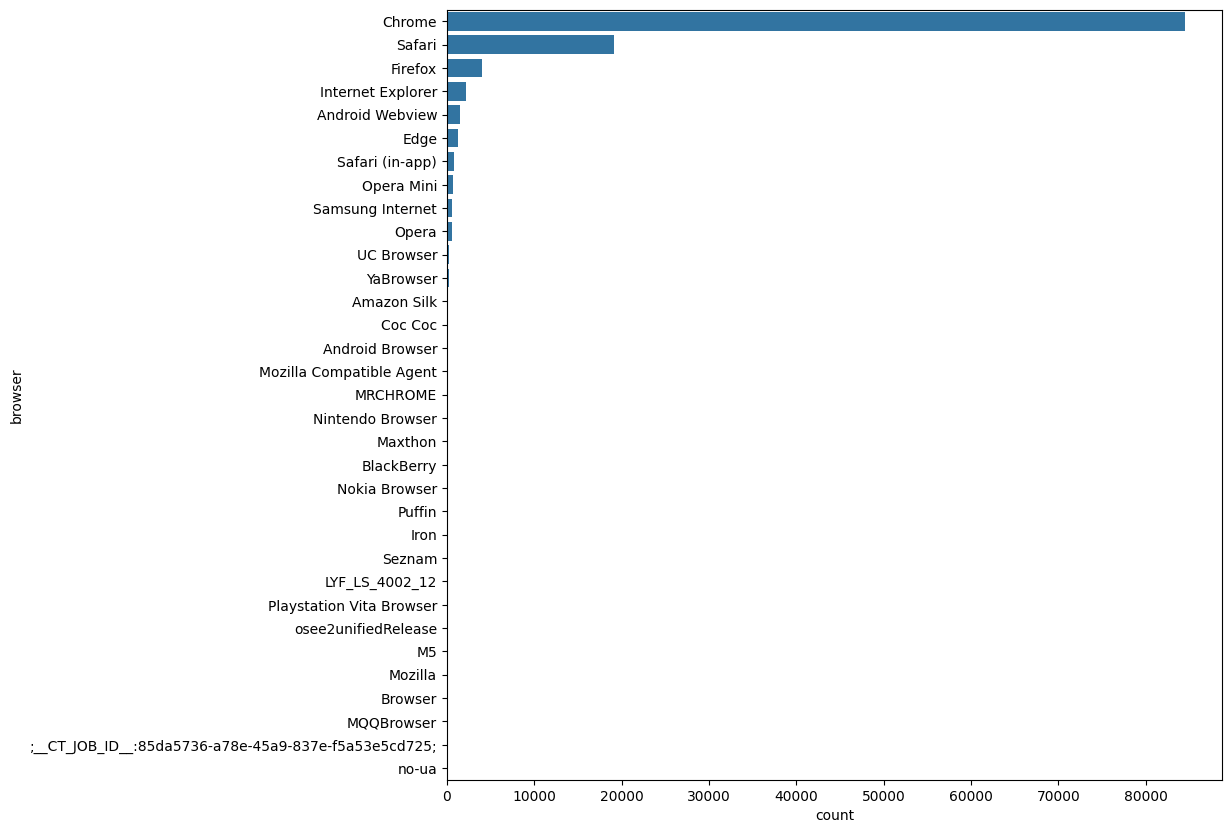

In [458]:
plt.figure(figsize=(10,10))
sns.countplot(y=train['browser'],order=train['browser'].value_counts().index)
plt.show()

#This would plot each purchase value against the browser used, letting you visually check if certain browsers are linked to higher purchase values

##clearly firefox and chrome are choice of majority users

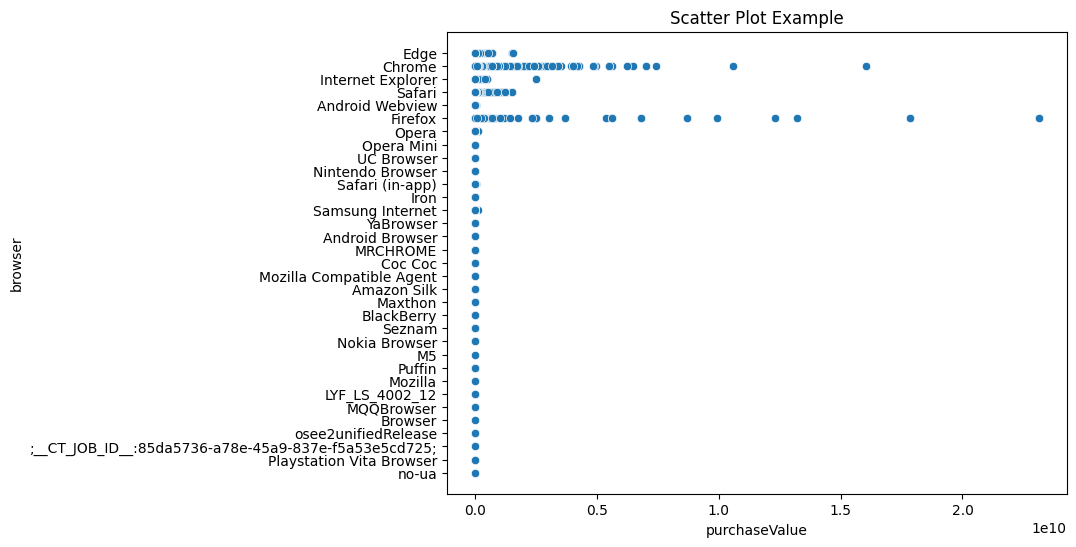

In [459]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=train['purchaseValue'], y=train['browser'])
plt.title('Scatter Plot Example')
plt.xlabel('purchaseValue')
plt.ylabel('browser')
plt.show()


#scatter plot with pageViews against purchaseValue

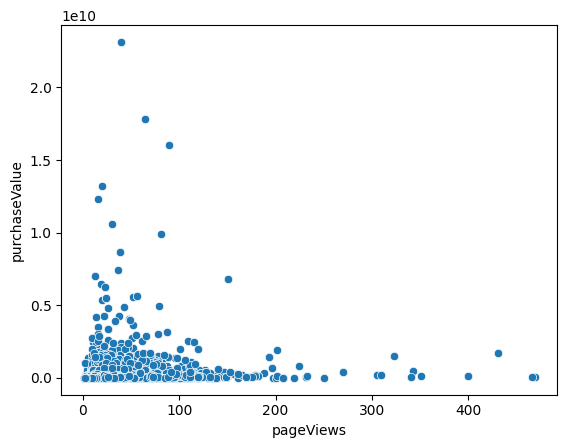

In [460]:
sns.scatterplot(x='pageViews',y='purchaseValue',data=train)
plt.show()

#since scatter plot is right skewed

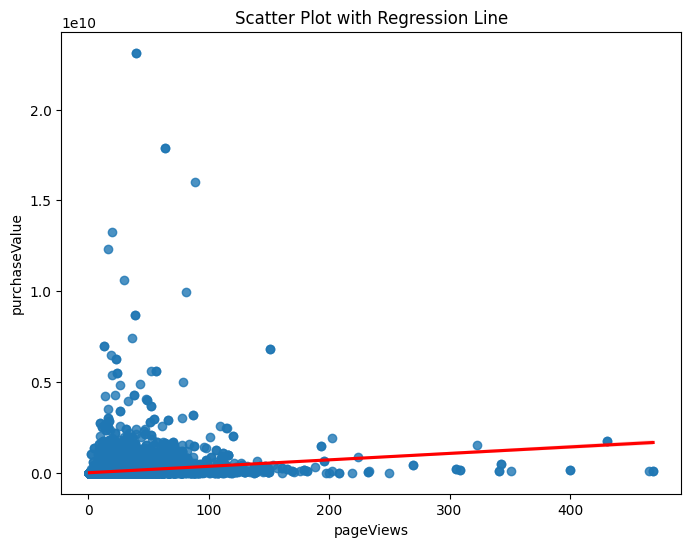

In [461]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.regplot(x='pageViews', y='purchaseValue', data=train, scatter=True, line_kws={'color':'red'})
plt.title('Scatter Plot with Regression Line')
plt.xlabel('pageViews')
plt.ylabel('purchaseValue')
plt.show()


In [462]:
#train = train.dropna(subset=['pageViews'])

In [463]:
#pearson corelation cofficient
import scipy.stats as stats

# Calculate Pearson correlation coefficient
r, p_value = stats.pearsonr(train['pageViews'], train['purchaseValue'])

print("Pearson correlation coefficient (r):", r)
print("p-value:", p_value)


Pearson correlation coefficient (r): nan
p-value: nan


In [464]:
# #log transormation is preprocessing
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. Apply log transformation to both features
# train['log_pageViews'] = np.log1p(train['pageViews'])
# train['log_purchaseValue'] = np.log1p(train['purchaseValue'])

# # 2. Plot the transformed data
# plt.figure(figsize=(8, 6))
# sns.scatterplot(x='log_pageViews', y='log_purchaseValue', data=train, alpha=0.5)

# plt.title('Log-Transformed Relationship')
# plt.xlabel('Log(pageViews + 1)')
# plt.ylabel('Log(purchaseValue + 1)')
# plt.show()

pageViews                            device.isMobile                       -0.150197
totalHits                            device.isMobile                       -0.146031
sessionId                            pageViews                             -0.079686
pageViews                            sessionStart                          -0.079686
sessionId                            totalHits                             -0.071529
totalHits                            sessionStart                          -0.071529
pageViews                            date                                  -0.068896
purchaseValue                        device.isMobile                       -0.064042
date                                 totalHits                             -0.063891
trafficSource.adwordsClickInfo.page  pageViews                             -0.056138
sessionNumber                        device.isMobile                       -0.052404
trafficSource.adwordsClickInfo.page  totalHits                   

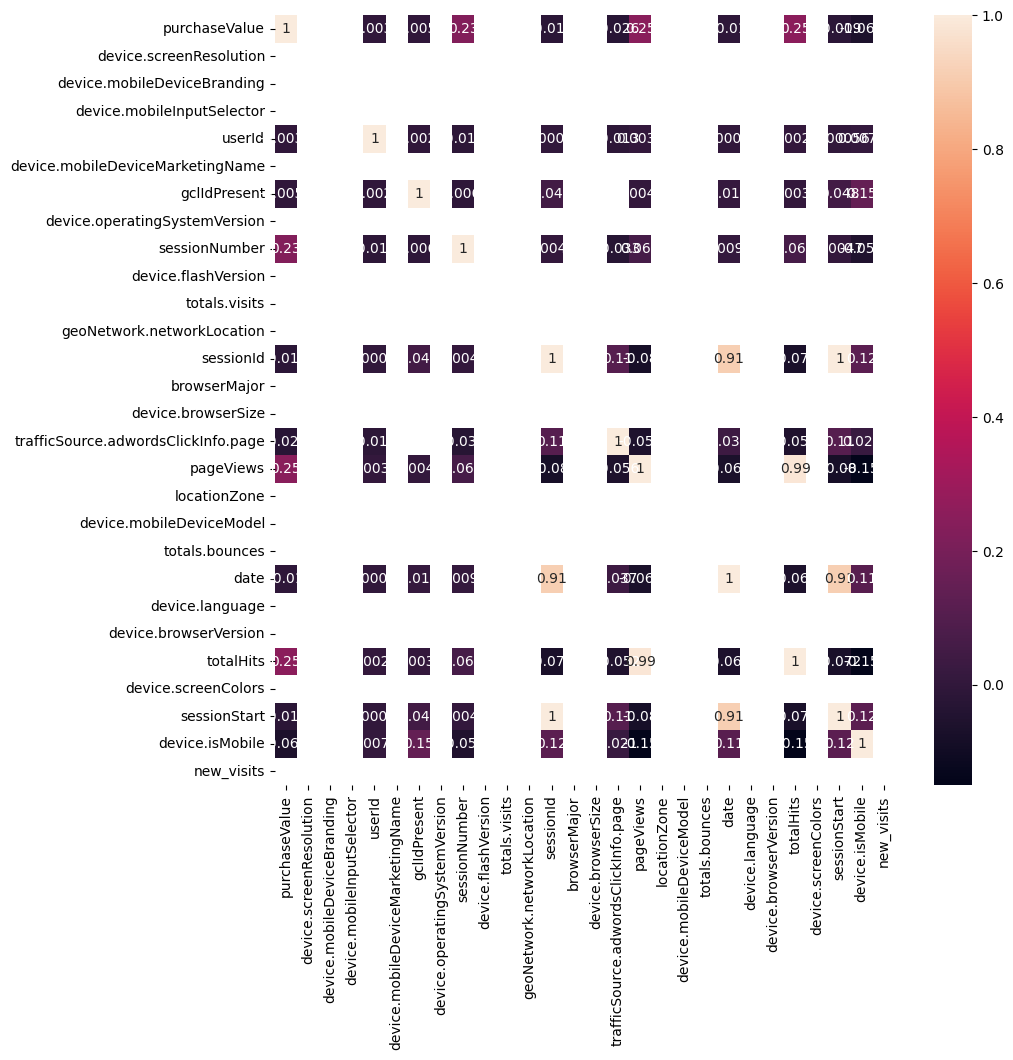

In [465]:
#coorelation coefficient between two variables
corr =train.select_dtypes(exclude='object').corr()

# Sort correlations in ascending order (excluding self-correlations)
sorted_corr = (
    corr.unstack()
        .drop_duplicates()   # remove duplicate pairs
        .sort_values(ascending=True)
)

print(sorted_corr)


plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)
plt.show()

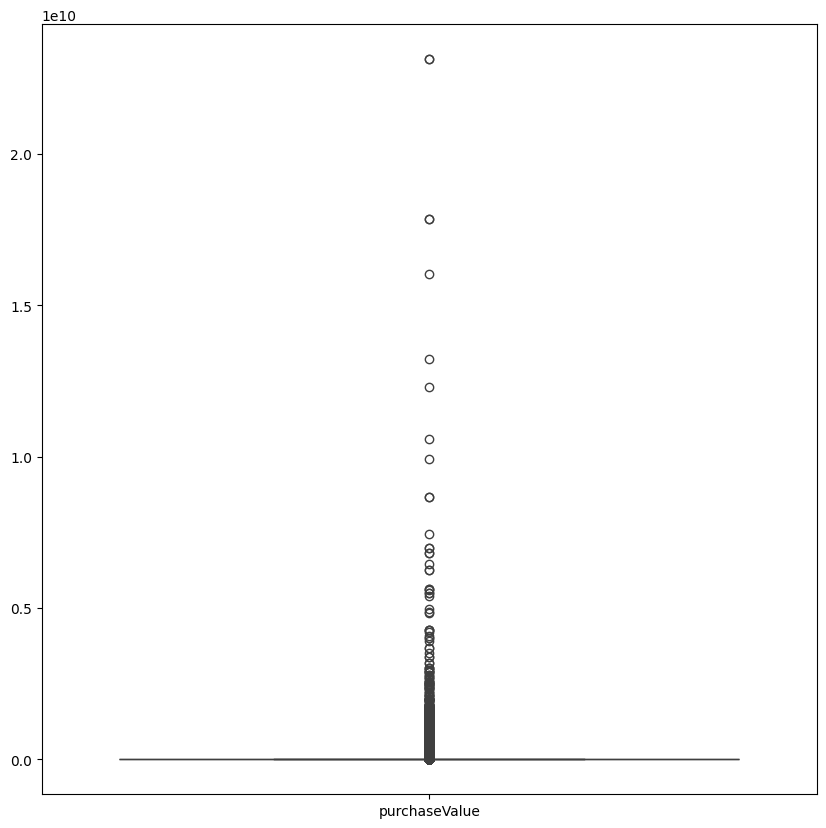

In [466]:
#box plot to detect outliers
plt.figure(figsize=(10,10))
sns.boxplot(data=train[['purchaseValue']])
plt.show()

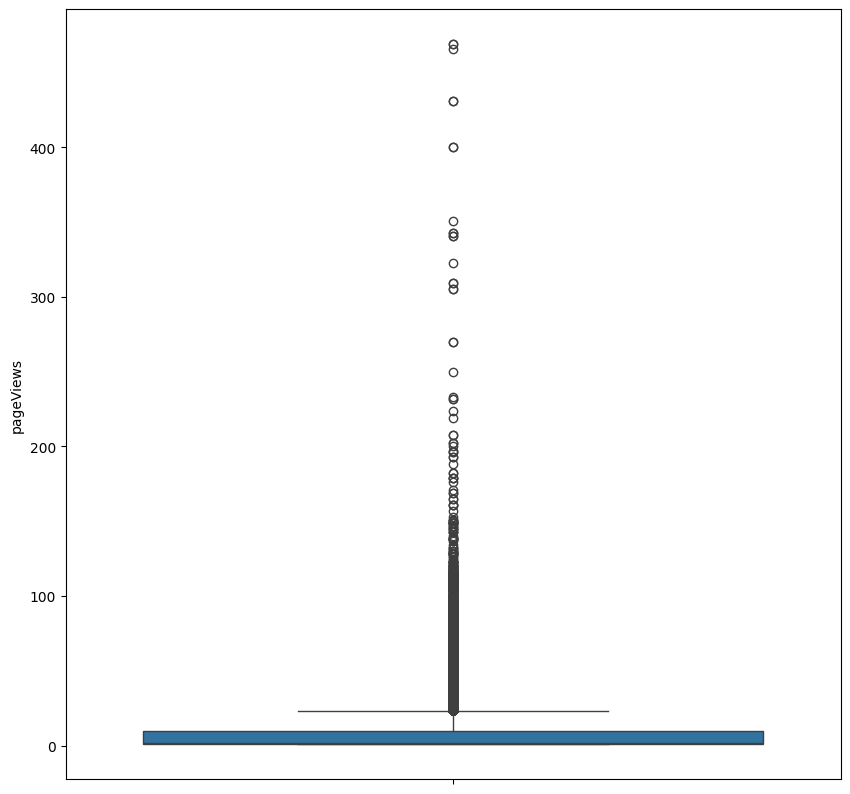

In [467]:
plt.figure(figsize=(10,10))
sns.boxplot(data=train['pageViews'])
plt.show()

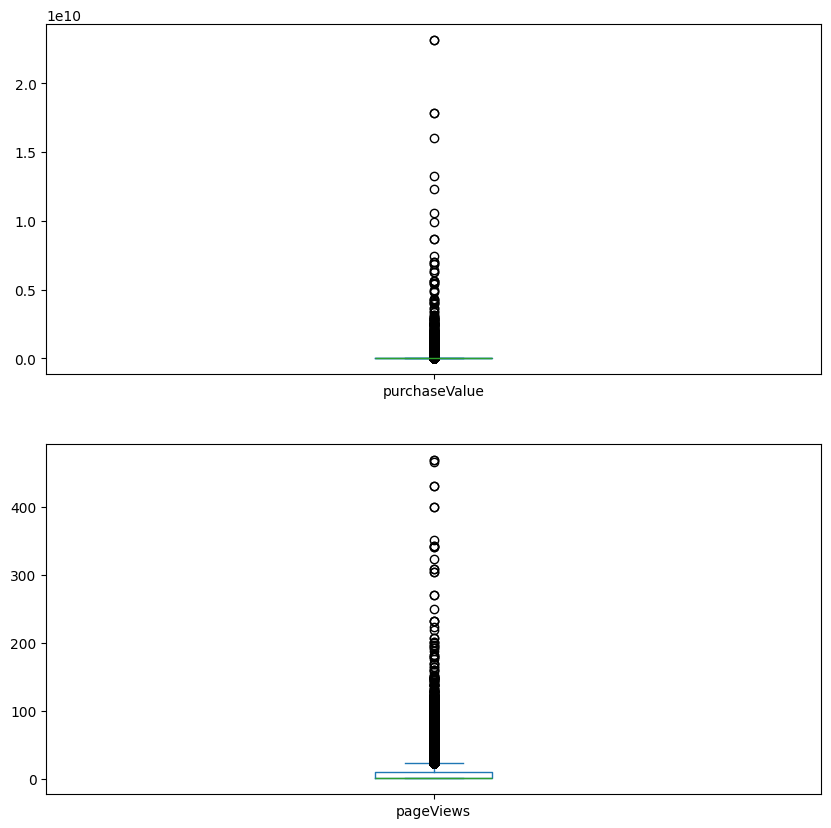

In [468]:
train[['purchaseValue','pageViews']].plot(kind='box', subplots=True, layout=(2,1), figsize=(10,10))
plt.show()


#encoding suggestions based on cardinality and category of data

In [469]:
train.shape

(116023, 52)

In [470]:
import pandas as pd

def suggest_encoding(train, threshold=10):
    suggestions = {}

    for col in train.columns:
        if train[col].dtype == 'object' or pd.api.types.is_categorical_dtype(train[col]):
            unique_vals = train[col].nunique()

            # Ordinal detection (simple heuristic: numeric categories)
            if all(isinstance(x, (int, float)) for x in train[col].dropna().unique()):
                suggestions[col] = f"{unique_vals} unique → Ordinal Encoding (numeric categories)"

            elif unique_vals <= threshold:
                suggestions[col] = f"{unique_vals} unique → One-Hot Encoding (few categories)"

            elif unique_vals > threshold and unique_vals <= 50:
                suggestions[col] = f"{unique_vals} unique → Label Encoding (medium cardinality, tree models)"

            else:
                suggestions[col] = f"{unique_vals} unique → Frequency / Target / Hash Encoding (high cardinality)"

        else:
            suggestions[col] = "Numeric Feature (no encoding needed)"

    return pd.DataFrame.from_dict(suggestions, orient='index', columns=['Cardinality & Suggested Encoding'])

# Example usage:
encoding_suggestions = suggest_encoding(train)
print(encoding_suggestions)



/tmp/ipykernel_3313/1283946841.py:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if train[col].dtype == 'object' or pd.api.types.is_categorical_dtype(train[col]):


                                                               Cardinality & Suggested Encoding
trafficSource.isTrueDirect                     1 unique → Ordinal Encoding (numeric categories)
purchaseValue                                              Numeric Feature (no encoding needed)
browser                                       33 unique → Label Encoding (medium cardinality...
device.screenResolution                                    Numeric Feature (no encoding needed)
trafficSource.adContent                       53 unique → Frequency / Target / Hash Encoding...
trafficSource.keyword                         565 unique → Frequency / Target / Hash Encodin...
screenSize                                         1 unique → One-Hot Encoding (few categories)
geoCluster                                         5 unique → One-Hot Encoding (few categories)
trafficSource.adwordsClickInfo.slot                3 unique → One-Hot Encoding (few categories)
device.mobileDeviceBranding             

## Q3. Perform Advanced Regex Text Cleaning

### Objective:
Apply text cleaning to the `trafficSource.keyword` column to standardize the raw text inputs.
### Remove:
- HTML Tags: `<.*?>`
- URLs: `http\S+`
- Emails: `\S+@\S+`
- Digits: `\d+`
- Special Characters: `[^a-zA-Z\s]`


#script to test unwanted character in training data

In [471]:
import re

def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_column = 'trafficSource.keyword'
train['clean_keyword'] = train[text_column].apply(clean_text)

train[[text_column, 'clean_keyword']].dropna().head(10)

,trafficSource.keyword,clean_keyword
37,google black women t shirt,google black women t shirt
65,+google +merchandise +store,google merchandise store
87,6qEhsCssdK0z36ri,qehscssdkzri
131,6qEhsCssdK0z36ri,qehscssdkzri
166,1hZbAqLCbjwfgOH7,hzbaqlcbjwfgoh
172,6qEhsCssdK0z36ri,qehscssdkzri
181,(automatic matching),automatic matching
186,6qEhsCssdK0z36ri,qehscssdkzri
188,(User vertical targeting),user vertical targeting
218,+Google +Merchandise,google merchandise


In [472]:
import re
import pandas as pd

# Load CSV file
#train = pd.read_csv("your_file.csv")   # replace with your actual CSV filename

def find_unwanted(text):
    if pd.isnull(text) or not isinstance(text, str):
        return None

    issues = []
    unwanted_chars = []

    # HTML tags
    if re.search(r'<.*?>', text):
        issues.append("Contains HTML tags → Suggest strip tags")
        unwanted_chars.extend(re.findall(r'<.*?>', text))

    # URLs
    if re.search(r'http\S+|www\S+|https\S+', text):
        issues.append("Contains URL → Suggest remove or replace")
        unwanted_chars.extend(re.findall(r'http\S+|www\S+|https\S+', text))

    # Emails
    if re.search(r'\S+@\S+', text):
        issues.append("Contains email → Suggest mask or remove")
        unwanted_chars.extend(re.findall(r'\S+@\S+', text))

    # Numbers
    if re.search(r'\d+', text):
        issues.append("Contains numbers → Suggest keep if numeric, else remove")
        unwanted_chars.extend(re.findall(r'\d+', text))

    # Special characters
    specials = re.findall(r'[^a-zA-Z0-9\s]', text)
    if specials:
        issues.append("Contains special characters → Suggest clean punctuation")
        unwanted_chars.extend(specials)

    if issues:
        return {"issues": issues, "unwanted": list(set(unwanted_chars))}
    return None

# Apply check only to text (object) columns
report = {}
text_cols = train.select_dtypes(include=['object']).columns

for col in text_cols:
    flagged = train[col].apply(find_unwanted).dropna()
    if not flagged.empty:
        report[col] = flagged.head(5).to_dict()  # show first 5 problematic rows

# Print report
for col, rows in report.items():
    print(f"Column: {col}")
    for idx, details in rows.items():
        print(f"  Row {idx}:")
        print(f"    Issues: {', '.join(details['issues'])}")
        print(f"    Unwanted Characters Found: {details['unwanted']}")
    print("-"*50)



Column: browser
  Row 327:
    Issues: Contains special characters → Suggest clean punctuation
    Unwanted Characters Found: ['(', ')', '-']
  Row 874:
    Issues: Contains special characters → Suggest clean punctuation
    Unwanted Characters Found: ['(', ')', '-']
  Row 1034:
    Issues: Contains special characters → Suggest clean punctuation
    Unwanted Characters Found: ['(', ')', '-']
  Row 1098:
    Issues: Contains special characters → Suggest clean punctuation
    Unwanted Characters Found: ['(', ')', '-']
  Row 1425:
    Issues: Contains special characters → Suggest clean punctuation
    Unwanted Characters Found: ['(', ')', '-']
--------------------------------------------------
Column: trafficSource.adContent
  Row 328:
    Issues: Contains numbers → Suggest keep if numeric, else remove
    Unwanted Characters Found: ['280', '336']
  Row 473:
    Issues: Contains numbers → Suggest keep if numeric, else remove, Contains special characters → Suggest clean punctuation
    Unw

In [473]:
train.head()

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits,clean_keyword
0,NaN,0.0,Edge,NaN,NaN,NaN,medium,Region_2,NaN,NaN,...,desktop,Social,NaN,1,NaN,1500100799,Americas,False,1.0,NaN
1,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,desktop,Direct,NaN,1,NaN,1495262065,Americas,False,1.0,NaN
2,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_2,NaN,NaN,...,desktop,Organic Search,NaN,6,NaN,1508510328,Europe,False,NaN,NaN
3,NaN,0.0,Internet Explorer,NaN,NaN,NaN,medium,Region_4,NaN,NaN,...,desktop,Social,NaN,1,NaN,1483431838,Asia,False,1.0,NaN
4,True,88950000.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,desktop,Direct,NaN,66,NaN,1475804633,Americas,False,1.0,NaN


## Q4. Handle Missing Values (Mean & Mode Imputation)

### Numerical: Mean or Mode Imputation
### Categorical: Mode Imputation

*(Note: For the remainder of the exercise, we isolate a subset of core features to demonstrate the concepts clearly)*


In [474]:
from sklearn.impute import SimpleImputer

# Select a subset of features for demonstration
num_cols = ['totalHits', 'pageViews', 'sessionNumber', 'new_visits']
cat_cols = ['browser', 'os', 'deviceType', 'userChannel']

num_imputer = SimpleImputer(strategy='mean')
train[num_cols] = num_imputer.fit_transform(train[num_cols])

In [475]:
cat_imputer = SimpleImputer(strategy='most_frequent')
train[cat_cols] = cat_imputer.fit_transform(train[cat_cols])

In [476]:
train[num_cols + cat_cols].isna().sum()

,0
totalHits,0
pageViews,0
sessionNumber,0
new_visits,0
browser,0
os,0
deviceType,0
userChannel,0


In [477]:
import pandas as pd

def impute_browser(val):
    if pd.isnull(val) or val.strip().lower() == "(not set)":
        return "Unknown"
    if "job_id" in val.lower() or "ct_" in val.lower():
        return "Unknown"
    if "Safari (in-app)":
        return "Safari"
    if "no-ua":
        return "Unknown"
    if val.startswith("LYF_") or val.startswith("LS_"):
        return "Mobile Browser"
    return val

train['browser_cleaned'] = train['browser'].apply(impute_browser)


In [478]:
#print(train[['browser']])
#print(train['browser'].tolist())
browser_df = train[['browser']]
all_values = browser_df['browser'].tolist()
print(all_values)



['Edge', 'Chrome', 'Chrome', 'Internet Explorer', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Android Webview', 'Safari', 'Chrome', 'Firefox', 'Chrome', 'Chrome', 'Safari', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Firefox', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Firefox', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Internet Explorer', 'Chrome', 'Chrome', 'Firefox', 'Safari', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Opera', 'Safari', 'Safari', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Safari', 'Chrome', 'Safari', 'Opera Mini', 'Chrome', 'Chrome', 'Chrome', 'Ch

In [479]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 54 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       0 non-null       float64
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         5096 non-null    object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   0 

## Q5. Apply OneHot Encoding

Transforms categorical variables into binary vectors.


In [480]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(train[cat_cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out())
encoded_df.head()

,browser_;__CT_JOB_ID__:85da5736-a78e-45a9-837e-f5a53e5cd725;,browser_Amazon Silk,browser_Android Browser,browser_Android Webview,browser_BlackBerry,browser_Browser,browser_Chrome,browser_Coc Coc,browser_Edge,browser_Firefox,...,deviceType_mobile,deviceType_tablet,userChannel_(Other),userChannel_Affiliates,userChannel_Direct,userChannel_Display,userChannel_Organic Search,userChannel_Paid Search,userChannel_Referral,userChannel_Social
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Q6. Apply Label Encoding on Target Variable

Since our problem statement predicts numerical `purchaseValue` (Regression), let's simulate the classification task by discretizing our target variable into tiers ('None', 'Low', 'High') and applying Label Encoding.


In [481]:
from sklearn.preprocessing import LabelEncoder

target_column = 'purchaseValue'

# Binning the numerical target into categories
train['purchase_tier'] = pd.cut(train[target_column].fillna(0),
                             bins=[-1, 0, 100000000, np.inf],
                             labels=['No_Purchase', 'Low_Value', 'High_Value'])

le = LabelEncoder()
train['target_encoded'] = le.fit_transform(train['purchase_tier'])

train[[target_column, 'purchase_tier', 'target_encoded']].head(10)

,purchaseValue,purchase_tier,target_encoded
0,0.0,No_Purchase,2
1,0.0,No_Purchase,2
2,0.0,No_Purchase,2
3,0.0,No_Purchase,2
4,88950000.0,Low_Value,1
5,28000000.0,Low_Value,1
6,80510000.0,Low_Value,1
7,0.0,No_Purchase,2
8,0.0,No_Purchase,2
9,0.0,No_Purchase,2


## Q7. Apply Target Encoding

Replace category with mean of target. We will target-encode `userChannel` against the original `purchaseValue`.


In [482]:
# We fill NaN in target to calculate a valid mean
target_mean = train.groupby('userChannel')['purchaseValue'].mean()
train['target_encoded_channel'] = train['userChannel'].map(target_mean)

train[['userChannel', 'target_encoded_channel']].drop_duplicates().head(40)

,userChannel,target_encoded_channel
0,Social,4.696204e+05
1,Direct,4.332910e+07
2,Organic Search,1.469966e+07
5,Referral,5.917188e+07
45,Affiliates,6.340180e+05
65,Paid Search,2.711639e+07
120,Display,7.514455e+07
12779,(Other),1.998000e+06


## Q8. Apply StandardScaler


In [483]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
train_std = scaler_std.fit_transform(train[num_cols])

pd.DataFrame(train_std, columns=num_cols).head()

,totalHits,pageViews,sessionNumber,new_visits
0,-0.489436,-0.516743,-0.161824,0.0
1,-0.489436,-0.516743,-0.161824,0.0
2,-0.234717,-0.168174,-0.066144,0.0
3,-0.489436,-0.516743,-0.161824,0.0
4,2.821908,3.178084,-0.161824,0.0


## Q9. Apply MinMaxScaler


In [484]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
train_mm = scaler_mm.fit_transform(train[num_cols])

print(pd.DataFrame(train_mm, columns=num_cols).head())

   totalHits  pageViews  sessionNumber  new_visits
0   0.000000   0.000000       0.000000         0.0
1   0.000000   0.000000       0.000000         0.0
2   0.010020   0.010684       0.002242         0.0
3   0.000000   0.000000       0.000000         0.0
4   0.130261   0.113248       0.000000         0.0


## Q10. Apply MaxAbsScaler


In [485]:
from sklearn.preprocessing import MaxAbsScaler

scaler_ma = MaxAbsScaler()
train_ma = scaler_ma.fit_transform(train[num_cols])

print(pd.DataFrame(train_ma, columns=num_cols).head())

   totalHits  pageViews  sessionNumber  new_visits
0      0.002   0.002132       0.002237         1.0
1      0.002   0.002132       0.002237         1.0
2      0.012   0.012793       0.004474         1.0
3      0.002   0.002132       0.002237         1.0
4      0.132   0.115139       0.002237         1.0


## Q11. Convert Date Column & Extract Time Features

Extract:
- Year
- Month
- Day
- Day of Week
- Is Weekend


In [486]:
date_column = 'date'

# The date is stored as an integer (e.g. 20170714)
train[date_column] = pd.to_datetime(train[date_column].astype(str), format='%Y%m%d')

train['year'] = train[date_column].dt.year
train['month'] = train[date_column].dt.month
train['day'] = train[date_column].dt.day
train['day_of_week'] = train[date_column].dt.dayofweek
train['is_weekend'] = train['day_of_week'].isin([5, 6]).astype(int)

train[[date_column, 'year', 'month', 'day', 'is_weekend']].head()

,date,year,month,day,is_weekend
0,2017-07-14,2017,7,14,0
1,2017-05-19,2017,5,19,0
2,2017-10-20,2017,10,20,0
3,2017-01-03,2017,1,3,0
4,2016-10-06,2016,10,6,0


## Q12. Create Lag Features


In [487]:
# Sort chronologically before lagging
train = train.sort_values(by=['userId', date_column])

train['lag_1_hits'] = train.groupby('userId')['totalHits'].shift(1)

train[['userId', date_column, 'totalHits', 'lag_1_hits']].dropna().head()

,userId,date,totalHits,lag_1_hits
53937,11,2017-04-28,14.0,14.0
110924,14,2018-03-27,13.0,28.0
109012,27,2016-10-20,14.0,14.0
112627,32,2016-12-12,2.0,2.0
30395,42,2016-12-21,22.0,22.0


## Q13. Create Rolling Mean & Std


In [488]:
train['rolling_mean_3_hits'] = train.groupby('userId')['totalHits'].rolling(3).mean().reset_index(0, drop=True)
train['rolling_std_3_hits'] = train.groupby('userId')['totalHits'].rolling(3).std().reset_index(0, drop=True)

train[['userId', 'totalHits', 'rolling_mean_3_hits', 'rolling_std_3_hits']].dropna().head()

,userId,totalHits,rolling_mean_3_hits,rolling_std_3_hits
59884,130,11.0,8.666667,2.516611
16441,163,1.0,15.333333,24.826062
71263,203,94.0,107.333333,23.094011
50172,279,1.0,12.000000,17.349352
56897,279,32.0,21.666667,17.897858


## Q14. Feature Selection using VarianceThreshold


In [489]:
from sklearn.feature_selection import VarianceThreshold

numeric_df = train.select_dtypes(include=np.number).fillna(0)

selector = VarianceThreshold(threshold=0.0)
selected_features = selector.fit_transform(numeric_df)

print("Selected Feature Shape:", selected_features.shape)

Selected Feature Shape: (116023, 20)


## Q15. Dimensionality Reduction using PCA


In [490]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(numeric_df)

print("Original Shape:", numeric_df.shape)
print("Reduced Shape:", reduced.shape)
# pca_df = pd.DataFrame(reduced, columns=['PC1', 'PC2'])
# pca_df.head()

Original Shape: (116023, 36)
Reduced Shape: (116023, 2)


## Q16. Train-Test Split


In [491]:
from sklearn.model_selection import train_test_split

# Dropping generated target proxy columns to avoid leakage
X = numeric_df.drop(columns=['purchaseValue', 'target_encoded', 'target_encoded_channel'], errors='ignore')
y = train['purchaseValue'].fillna(0)  # Core competition objective

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (92818, 33)
Test Shape: (23205, 33)


## Q17. Define Numeric and Categorical Preprocessing Pipelines

Create pipelines for:

1. Numerical Features
   - Median Imputation
   - Standard Scaling

2. Categorical Features
   - Mode Imputation
   - OneHot Encoding


In [492]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['totalHits', 'pageViews', 'sessionNumber', 'new_visits']
categorical_features = ['browser', 'os', 'deviceType', 'userChannel']

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['totalHits', 'pageViews', 'sessionNumber', 'new_visits']
Categorical Features: ['browser', 'os', 'deviceType', 'userChannel']


In [493]:
# Numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [494]:
# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

## Q18. Combine Numeric and Categorical Pipelines using ColumnTransformer

Use ColumnTransformer to apply:
- Numeric pipeline → only on numeric features
- Categorical pipeline → only on categorical features


In [495]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['totalHits', 'pageViews', 'sessionNumber',
                                  'new_visits']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['browser', 'os', 'deviceType',
                                  'userChannel'])])

## End of Notebook